##Pneumonia Detection Project
<img src = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSb9MO1T2nFoxVNBXEpzkyt7-KiVtgizGsQCA&s">

##Phase 1 : Data Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Path to dataset files: archive/chest_xray


Preprocessing for native built model

In [3]:
import cv2
import numpy as np

def center_crop_image(img, crop_factor=0.85):
    """
    Crops the center portion of the image.
    crop_factor=0.85 means it removes 7.5% from each edge.
    """
    h, w = img.shape[:2]
    new_h, new_w = int(h * crop_factor), int(w * crop_factor)

    start_x = (w - new_w) // 2
    start_y = (h - new_h) // 2

    cropped = img[start_y:start_y+new_h, start_x:start_x+new_w]
    return cropped

# This function will be used by ImageDataGenerator's preprocessing_function
def apply_crop_and_resize(img_array, target_size, crop_factor=0.85):
    # Ensure img_array is in uint8 for cv2 operations
    img = img_array.astype('uint8')

    # 1. Apply the Center Crop to the raw image
    cropped_img = center_crop_image(img, crop_factor=crop_factor)

    # 2. Resize the cropped image to the target_size
    resized_img = cv2.resize(cropped_img, target_size)

    # Return the image as float32, not yet normalized (rescale will do that in ImageDataGenerator)
    return resized_img.astype('float32')

In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use your custom cropping and resizing logic inside the generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: apply_crop_and_resize(x, IMG_SIZE, 0.85),
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Set validation split
)

In [6]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: apply_crop_and_resize(x, IMG_SIZE, 0.85)
)

In [7]:
train_data = train_datagen.flow_from_directory(
    path +"/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset='training'
)

Found 4173 images belonging to 2 classes.


In [9]:
from sklearn.utils.validation import column_or_1d
val_data = train_datagen.flow_from_directory(
    path+"/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset='validation' # This now works because validation_split is set in train_datagen
)

Found 1043 images belonging to 2 classes.


In [10]:
test_data = val_test_datagen.flow_from_directory(
    path+"/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle = False

)

Found 624 images belonging to 2 classes.


In [11]:
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
images, labels = next(train_data)
print(images.shape)
print(labels[:10])


(32, 224, 224, 3)
[1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
timages, tlabels = next(test_data)
print(images.shape)
print(labels[:10])

(32, 224, 224, 3)
[1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


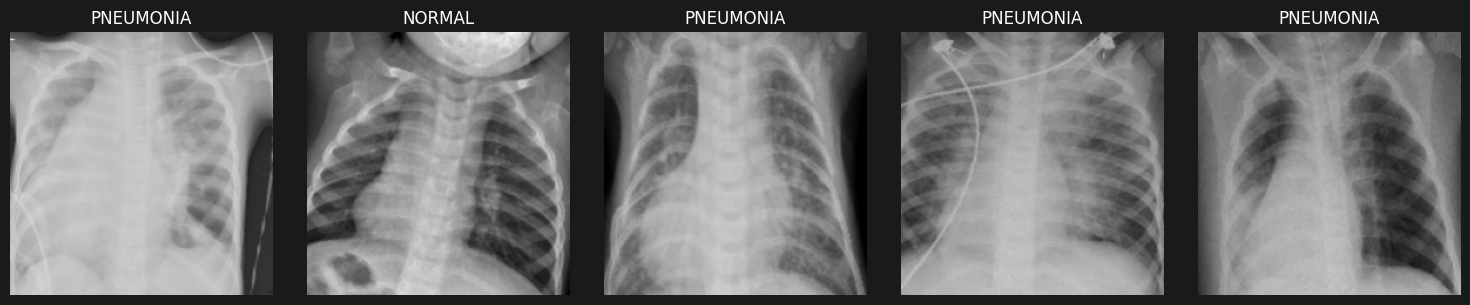

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels
images, labels = next(train_data)

# Get class names from train_data.class_indices
class_names = {v: k for k, v in train_data.class_indices.items()}

# Plot a few images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    ax.imshow(images[i])
    ax.set_title(class_names[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

### Class Distribution Across Dataset Splits
Let's analyze the class distribution for the training, validation, and test datasets to check for balance and consistency.

/tmp/ipykernel_13464/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


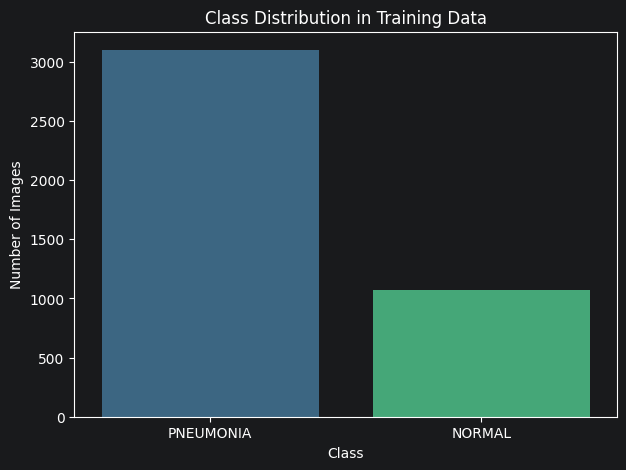

/tmp/ipykernel_13464/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


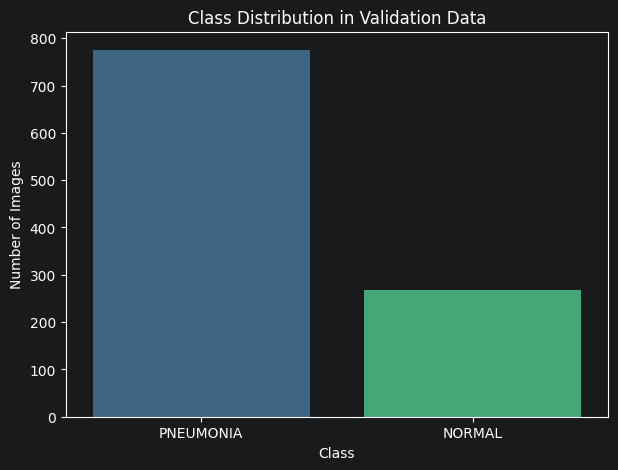

/tmp/ipykernel_13464/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


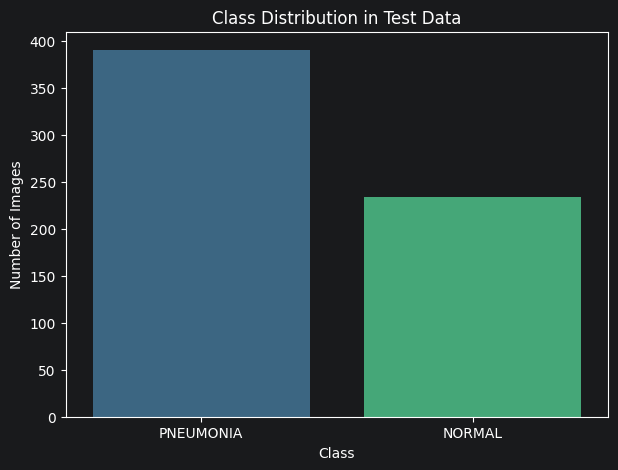

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(data_generator, title):
    """Plots the class distribution for a given data generator."""
    class_labels = data_generator.classes
    class_names = {v: k for k, v in data_generator.class_indices.items()}
    class_counts = pd.Series(class_labels).map(class_names).value_counts()

    plt.figure(figsize=(7, 5))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()

# Plot distribution for training data
plot_class_distribution(train_data, 'Class Distribution in Training Data')

# Plot distribution for validation data
plot_class_distribution(val_data, 'Class Distribution in Validation Data')

# Plot distribution for test data
plot_class_distribution(test_data, 'Class Distribution in Test Data')

### Calculating Class Weights
To address the class imbalance, we can calculate class weights. This gives more importance to the minority class during training, preventing the model from becoming biased towards the majority class. The formula often used is `total_samples / (num_classes * num_samples_in_class)`.

In [15]:
# If you have 1000 Normal and 200 Pneumonia images:
weights = {0: 1.0, 1: 0.35} # Pay 5x more attention to class 1 (Pneumonia)

### How to use Class Weights in Model Training
Once you define your Keras model, you can pass the `class_weight_dict` to the `fit` method. For example:

```python
# Assuming 'model' is your compiled Keras model
# model.fit(
#     train_data,
#     epochs=...,
#     validation_data=val_data,
#     class_weight=class_weight_dict # Pass the calculated class weights here
# )
```

This will apply the calculated weights during the training process, helping your model learn more effectively from the underrepresented class.

In [53]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization,Dropout,Input,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [34]:



model = Sequential()
#1st Convolutional Layer for extracting features from the images
model.add(Conv2D(32,(5,5),activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

#2nd Conv Layer
model.add(Conv2D(64,(5,5),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

#3rd Conv Layer
model.add(Conv2D(128,(5,5),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

#Flatten Layer
model.add(Flatten())

#Dense Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Minority Class Targeted Augmentation
We can create a specialized generator that only pulls from the 'NORMAL' folder with higher augmentation parameters to help the model generalize better on the minority class.

/tmp/ipykernel_55/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


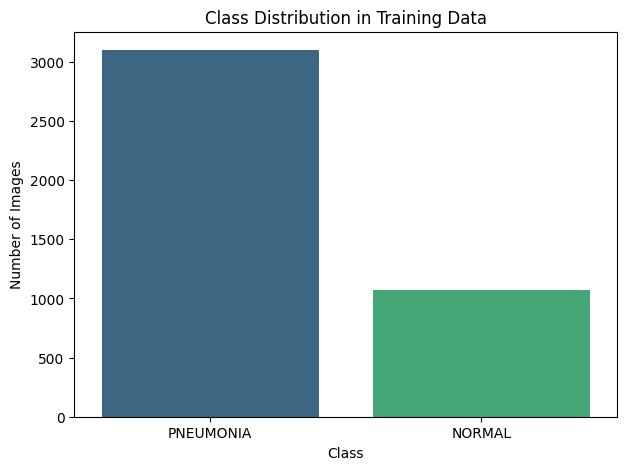

/tmp/ipykernel_55/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


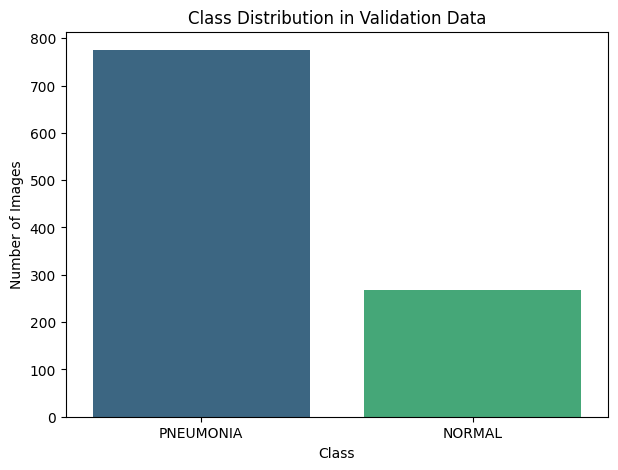

/tmp/ipykernel_55/642989467.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


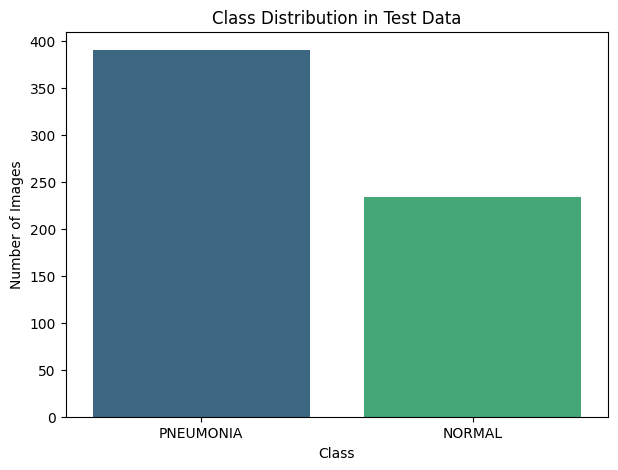

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(data_generator, title):
    """Plots the class distribution for a given data generator."""
    class_labels = data_generator.classes
    class_names = {v: k for k, v in data_generator.class_indices.items()}
    class_counts = pd.Series(class_labels).map(class_names).value_counts()

    plt.figure(figsize=(7, 5))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()

# Plot distribution for training data
plot_class_distribution(train_data, 'Class Distribution in Training Data')

# Plot distribution for validation data
plot_class_distribution(val_data, 'Class Distribution in Validation Data')

# Plot distribution for test data
plot_class_distribution(test_data, 'Class Distribution in Test Data')

Now you can train with this `augmented_balanced_train_data` generator. Because it's balanced, you usually don't need `class_weight` anymore.

In [16]:
model.summary()

NameError: name 'model' is not defined

In [37]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['recall','accuracy','precision'])

In [38]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
#

model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=weights,
    callbacks=[early_stop]
)

NameError: name 'train_ds' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get predictions from the test set
# Ensure shuffle=False in your test_generator to /keep labels in order
Y_pred = model.predict(test_data)
y_pred = (Y_pred > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Get the actual ground truth labels
y_true = test_data.classes # Corrected from validation_generator.classes

# 3. Print the Classification Report
target_names = ['NORMAL', 'PNEUMONIA'] # Use actual class names
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Generate and plot the Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

After fine-tuning, you should evaluate the model again using the test set to see if the performance has improved.

In [17]:
from tensorflow.keras.applications import DenseNet121

# Load pre-trained model without the top (classification) layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224, 3))

# Freeze the base
base_model.trainable = True

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 50s 2us/step


In [18]:
from tensorflow.keras import layers, models

Dense_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Recommended over Flatten
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Keep your dropout for regularization
    layers.Dense(1, activation='sigmoid')
])

In [19]:
from tensorflow.keras.optimizers import Adam

Dense_model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['recall','accuracy','precision'])

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
#

Dense_model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    class_weight=weights,
    callbacks=[early_stop]
)

Epoch 1/20
 11/131 ━━━━━━━━━━━━━━━━━━━━ 14:03 7s/step - accuracy: 0.5918 - loss: 0.4534 - precision: 0.7300 - recall: 0.7169

KeyboardInterrupt: 

In [1]:
import joblib

# Save the Dense_model using joblib
joblib.dump(Dense_model, '../models/Dense_model.joblib')

ModuleNotFoundError: No module named 'joblib'

In [ ]:
from google.colab import files
files.download('Dense_model.joblib')

In [2]:
Dense_model.save('Dense_model.h5')

NameError: name 'Dense_model' is not defined

In [3]:
from google.colab import files
files.download('Dense_model.h5')

ModuleNotFoundError: No module named 'google.colab'

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step 
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.80      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



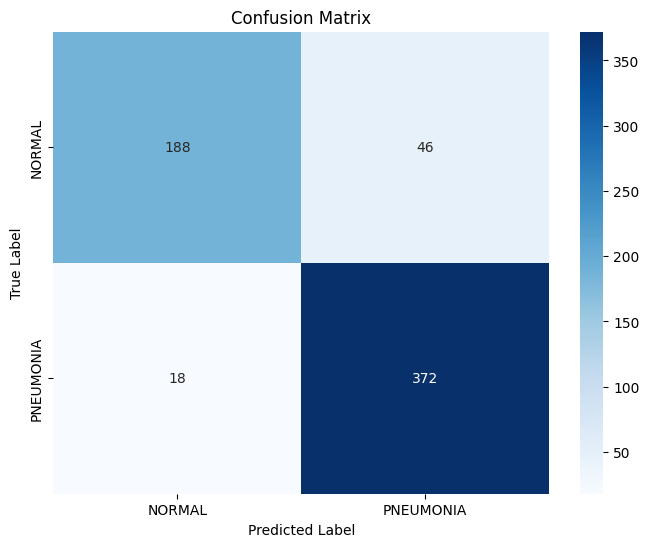

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf # Import tensorflow for dataset iteration

# 1. Get predictions from the test set
Y_pred = Dense_model.predict(test_data)
y_pred = (Y_pred > 0.66).astype(int) # Convert probabilities to 0 or 1

# 2. Get the actual ground truth labels from test_ds
y_true = test_data.classes # Corrected: Directly use test_data.classes

# 3. Print the Classification Report
target_names = ['NORMAL', 'PNEUMONIA'] # Use actual class names
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Generate and plot the Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step


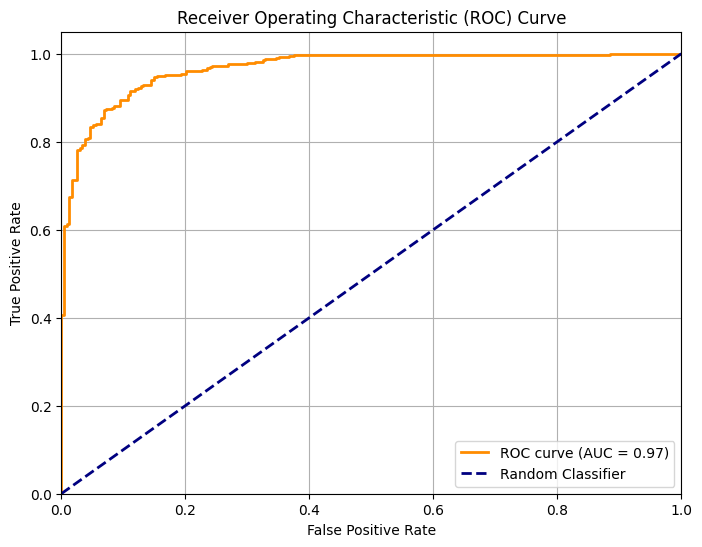

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (PNEUMONIA)
y_pred_proba = Dense_model.predict(test_data)[:, 0] # Assuming the model outputs probability for class 1

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

# Calculate AUC
roc_auc = roc_auc_score(y_true, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [69]:
import kagglehub
import os
import glob

# Download the RSNA dataset (JPG version)
rsna_path = kagglehub.dataset_download("sovitrath/rsna-pneumonia-detection-2018")

print("Path to RSNA dataset:", rsna_path)

Path to RSNA dataset: /kaggle/input/datasets/sovitrath/rsna-pneumonia-detection-2018


In [75]:
!pip install -q pydicom pylibjpeg pylibjpeg-libjpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 36.3 MB/s eta 0:00:0000:0100:01


In [78]:
import pydicom
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm

def convert_dcm_to_jpg(dcm_path, output_path):
    # 1. Read DICOM file
    ds = pydicom.dcmread(dcm_path)
    
    # 2. Extract pixel array
    img = ds.pixel_array
    
    # 3. Normalize to 0-255 (8-bit)
    img = img.astype(float)
    img = (img - np.min(img)) / (np.max(img) - np.min(img)) * 255.0
    img = img.astype(np.uint8)
    
    # 4. Save as JPG
    cv2.imwrite(output_path, img)

# --- Path Configuration ---
# Update these based on your Kaggle environment
dcm_folder = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"
csv_path = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"

# Load labels and sample 250 of each
df = pd.read_csv(csv_path)
normal_sample = df[df['Target'] == 0]['patientId'].unique()[:250]
pneumo_sample = df[df['Target'] == 1]['patientId'].unique()[:250]

# Create output directories
os.makedirs('RSNA_Test/Normal', exist_ok=True)
os.makedirs('RSNA_Test/Pneumonia', exist_ok=True)

# --- Execution ---
print("Converting Normal images...")
for pid in tqdm(normal_sample):
    convert_dcm_to_jpg(f"{dcm_folder}/{pid}.dcm", f"RSNA_Test/Normal/{pid}.jpg")

print("Converting Pneumonia images...")
for pid in tqdm(pneumo_sample):
    convert_dcm_to_jpg(f"{dcm_folder}/{pid}.dcm", f"RSNA_Test/Pneumonia/{pid}.jpg")

Converting Normal images...


100%|██████████| 250/250 [00:09<00:00, 27.12it/s]


Converting Pneumonia images...


100%|██████████| 250/250 [00:08<00:00, 27.99it/s]


In [82]:
def preprocess_and_crop(img_path, target_size=(224, 224)):
    # 1. Load the actual image data from the path (the string)
    img = cv2.imread(img_path)
    
    # SAFETY CHECK: If the path is wrong, imread returns None
    if img is None:
        raise ValueError(f"Could not open or find the image: {img_path}")
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Apply Center Crop (85% focus)
    h, w = img.shape[:2]
    new_h, new_w = int(h * 0.85), int(w * 0.85)
    start_x, start_y = (w - new_w) // 2, (h - new_h) // 2
    cropped = img[start_y:start_y+new_h, start_x:start_x+new_w]
    
    # 3. Resize
    resized_img = cv2.resize(cropped, target_size)
    
    # 4. NOW call .astype() on the NumPy array (not the string!)
    img_array = resized_img.astype('float32') / 255.0
    
    return img_array

In [97]:
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def test_on_rsna(model, test_dir):
    y_true = []
    y_pred = []
    
    # Categories match your folder names
    categories = ['Normal', 'Pneumonia']
    
    for label, category in enumerate(categories):
        path = os.path.join(test_dir, category)
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            
            # 1. Use the SAME preprocessing (Crop + Resize + Normalize)
            # Replace with your actual preprocessing function name
            img_array = preprocess_and_crop(img_path)
            
            # 2. Predict
            pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0][0]
            
            y_true.append(label)
            y_pred.append(1 if pred > 0.95 else 0)

    return y_true, y_pred

# Run the test
y_true, y_pred = test_on_rsna(Dense_model, 'RSNA_Test')

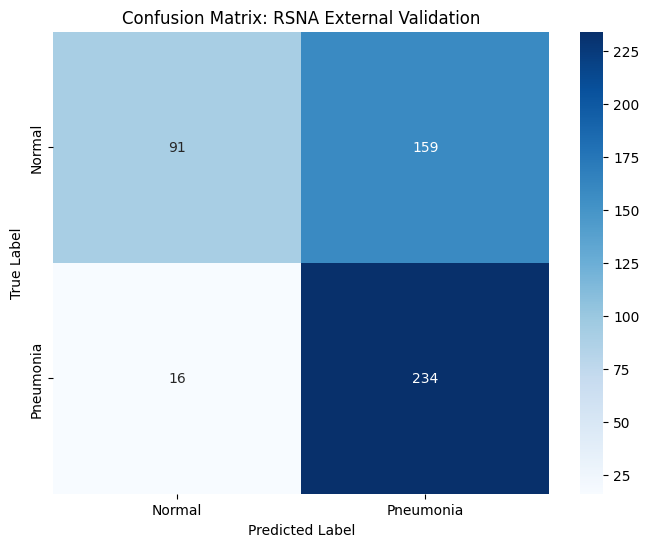


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.85      0.36      0.51       250
   Pneumonia       0.60      0.94      0.73       250

    accuracy                           0.65       500
   macro avg       0.72      0.65      0.62       500
weighted avg       0.72      0.65      0.62       500



In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate the raw confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: RSNA External Validation')
plt.show()

# 3. Print the text-based report for Precision and Recall
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

### Evaluate DenseNet Model on RSNA Mini Test Set
Now that we have prepared a small test set from the RSNA dataset, let's evaluate the performance of our trained DenseNet model on these new, unseen images.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator for the RSNA mini test set.
# Only rescaling is needed, no augmentation for evaluation.
rsna_test_datagen = ImageDataGenerator(rescale=1./255)

rsna_test_data = rsna_test_datagen.flow_from_directory(
    'RSNA_Mini_Test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

print(rsna_test_data.class_indices)

In [ ]:
print("Evaluating DenseNet model on RSNA Mini Test Set...")
# Evaluate the Dense_model on the RSNA mini test data
rsna_evaluation_results = Dense_model.evaluate(rsna_test_data)

# Print the evaluation metrics
print("\nRSNA Mini Test Set Evaluation Results:")
for name, value in zip(Dense_model.metrics_names, rsna_evaluation_results):
    print(f"{name}: {value:.4f}")

In [ ]:
Dense_model.evaluate(test_data)

In [63]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. 'Wake up' the model to define its output tensors
# This fixes the "never been called" error
_ = Dense_model(tf.zeros((1, 224, 224, 3)))

print("Model graph successfully initialized.")

Model graph successfully initialized.


In [64]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Get the base model (DenseNet121) from the sequential model
    base_model = model.layers[0]

    # 2. Create a sub-model that outputs both the last convolutional layer's activations
    # and the base model's full output (which feeds into the classifier).
    grad_cam_layer_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        # Cast the input image to float32 and ensure it's a tf.Tensor
        input_image_tensor = tf.cast(img_array, tf.float32)

        # Get the activations of the last conv layer and the base model's output
        last_conv_layer_output, base_model_output = grad_cam_layer_model(input_image_tensor)

        # Watch the last_conv_layer_output specifically for gradients
        tape.watch(last_conv_layer_output)

        # Pass the base_model_output through the rest of the classifier layers
        # of the original `model` to get the final predictions.
        x = base_model_output
        for layer in model.layers[1:]: # Skip the base_model itself
            x = layer(x)
        predictions = x # This is the final prediction of the entire model

        # Get the loss for the target class (Pneumonia, assumed to be index 0 for sigmoid output)
        loss = predictions[:, 0]

    # Compute gradients of the loss with respect to the last conv layer output
    grads = tape.gradient(loss, last_conv_layer_output)

    if grads is None:
        print("Warning: Gradients are None. This might indicate an issue with differentiability.")
        # Return a zero heatmap of the correct 2D shape (H, W)
        return np.zeros(last_conv_layer_output.shape[1:3], dtype=np.float32)

    # Global average pooling of gradients to get importance weights for each feature map channel
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))

    # Build the heatmap
    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension from activations
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis] # Element-wise multiply then sum across channels
    heatmap = tf.squeeze(heatmap) # Remove the last dimension (H_conv, W_conv)

    # Normalize heatmap for visualization (0 to 1)
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) == 0:
        return np.zeros(heatmap.shape, dtype=np.float32)
    heatmap = heatmap / tf.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Prediction Confidence for Pneumonia: 99.98%


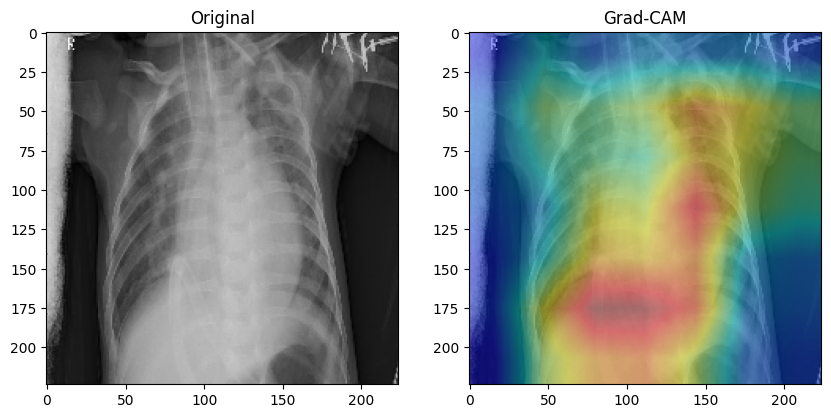

In [65]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# The standard last conv layer for DenseNet121
LAST_CONV_LAYER = "conv5_block16_2_conv"

# 1. Pick an image path from the test set
img_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person128_bacteria_607.jpeg"

# 2. Preprocess the image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0 # Add batch dim and normalize

# 3. Predict and Visualize
prediction = Dense_model.predict(img_array)[0][0]
print(f"Prediction Confidence for Pneumonia: {prediction:.2%}")

heatmap = get_gradcam_heatmap(img_array, Dense_model, LAST_CONV_LAYER)
display_gradcam(img_path, heatmap)
